##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt

from svipy.vae import vaeEncoder, vaeDecoder, variationalAutoencoder, vqVariationalAutoencoder, autoencodingVariationalAutoencoder
from svipy.rbm import restrictedBoltzmannMachine
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)
# trainData = datasets.MNIST(root="../data", train=True, download=True) # , transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


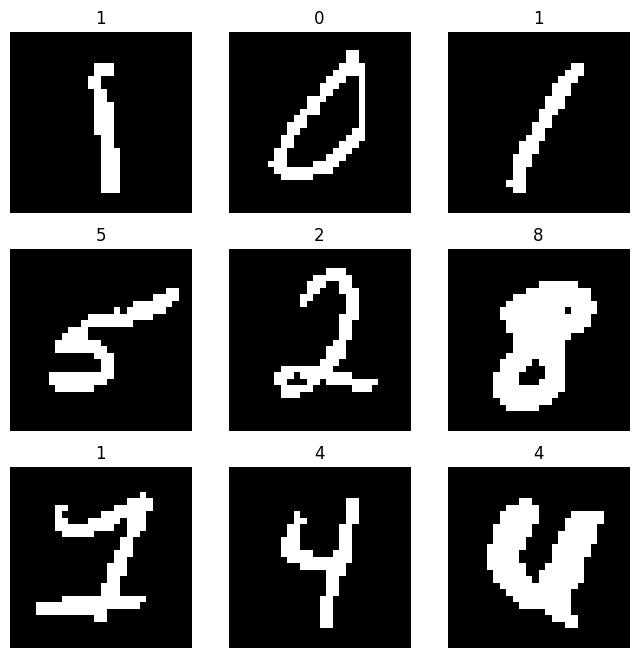

In [4]:
# show some randomly picked numbers
label_map = {k: str(k) for k in range(10)}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(label_map[torch.argmax(label, dim=0).item()])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

###### Hardware Specs

In [5]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


In [6]:
# inference
def latentSpaceRecons2D(n=30, figsize=15, scale=1.0):
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))
    
    # linearly spaced coordinates corresponding in the 2D latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = model.decoder(z_sample)[0].cpu().detach()
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size,
                   j * digit_size : (j + 1) * digit_size] = digit

    plt.figure(figsize=(figsize, figsize))
    
    # set axis ticks corresponding to latent values
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 1))

    # axis labels
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


def activeUnits(model, dataset, threshold=0.01, batchSize=256, device=device):
    """
    Burda et al.'s "active units" statistic: Var_x[mu(x)] per latent
    dimension, computed across the dataset. A dimension whose posterior
    mean barely moves across different inputs is \"dead\" -- carrying no
    information about x, regardless of what its logVar looks like.
    """
    
    model.eval()
    loader = DataLoader(dataset, batch_size=batchSize, shuffle=False)
    means = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            zMean, _ = model.encode(data)
            means.append(zMean.cpu())
    means = torch.cat(means, dim=0)
    
    variance = means.var(dim=0)
    nActive = 0
    for i, v in enumerate(variance):
        active = v.item() > threshold
        nActive += active
        print(f"dim {i}: Var_x[mu] = {v.item():.6f}  ({'active' if active else 'DEAD'})")
    
    print(f"{nActive}/{len(variance)} active units (threshold={threshold})")          
    return variance


##### MNIST

###### Variational Autoencoder

In [7]:
class mnistDecoder(vaeDecoder):
    '''
    VAE decoder with cross entropy loss (canonical decoder uses MSE)
    '''
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))

In [8]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = variationalAutoencoder(encoder, decoder).to(device)

In [9]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [10]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_vae/',
                checkPointName='vae_2',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 203.444519 reconLoss: 200.495361 klLoss: 2.949164[12800/60000]
totalLoss: 192.766144 reconLoss: 189.680328 klLoss: 3.085822[25600/60000]
totalLoss: 165.588379 reconLoss: 162.338516 klLoss: 3.249855[38400/60000]
totalLoss: 170.566589 reconLoss: 167.370712 klLoss: 3.195879[51200/60000]
Validation Error: 167.450846
Epoch 2
-------------------------------
totalLoss: 161.194672 reconLoss: 157.891357 klLoss: 3.303307[12800/60000]
totalLoss: 154.930847 reconLoss: 151.774353 klLoss: 3.156492[25600/60000]
totalLoss: 157.202866 reconLoss: 153.898911 klLoss: 3.303957[38400/60000]
totalLoss: 159.564575 reconLoss: 156.306473 klLoss: 3.258095[51200/60000]
Validation Error: 160.626805
Epoch 3
-------------------------------
totalLoss: 149.839233 reconLoss: 146.453827 klLoss: 3.385411[12800/60000]
totalLoss: 161.399551 reconLoss: 158.079529 klLoss: 3.320021[25600/60000]
totalLoss: 152.938950 reconLoss: 149.473145 klLoss: 3.465804[38400/60000]
totalLos

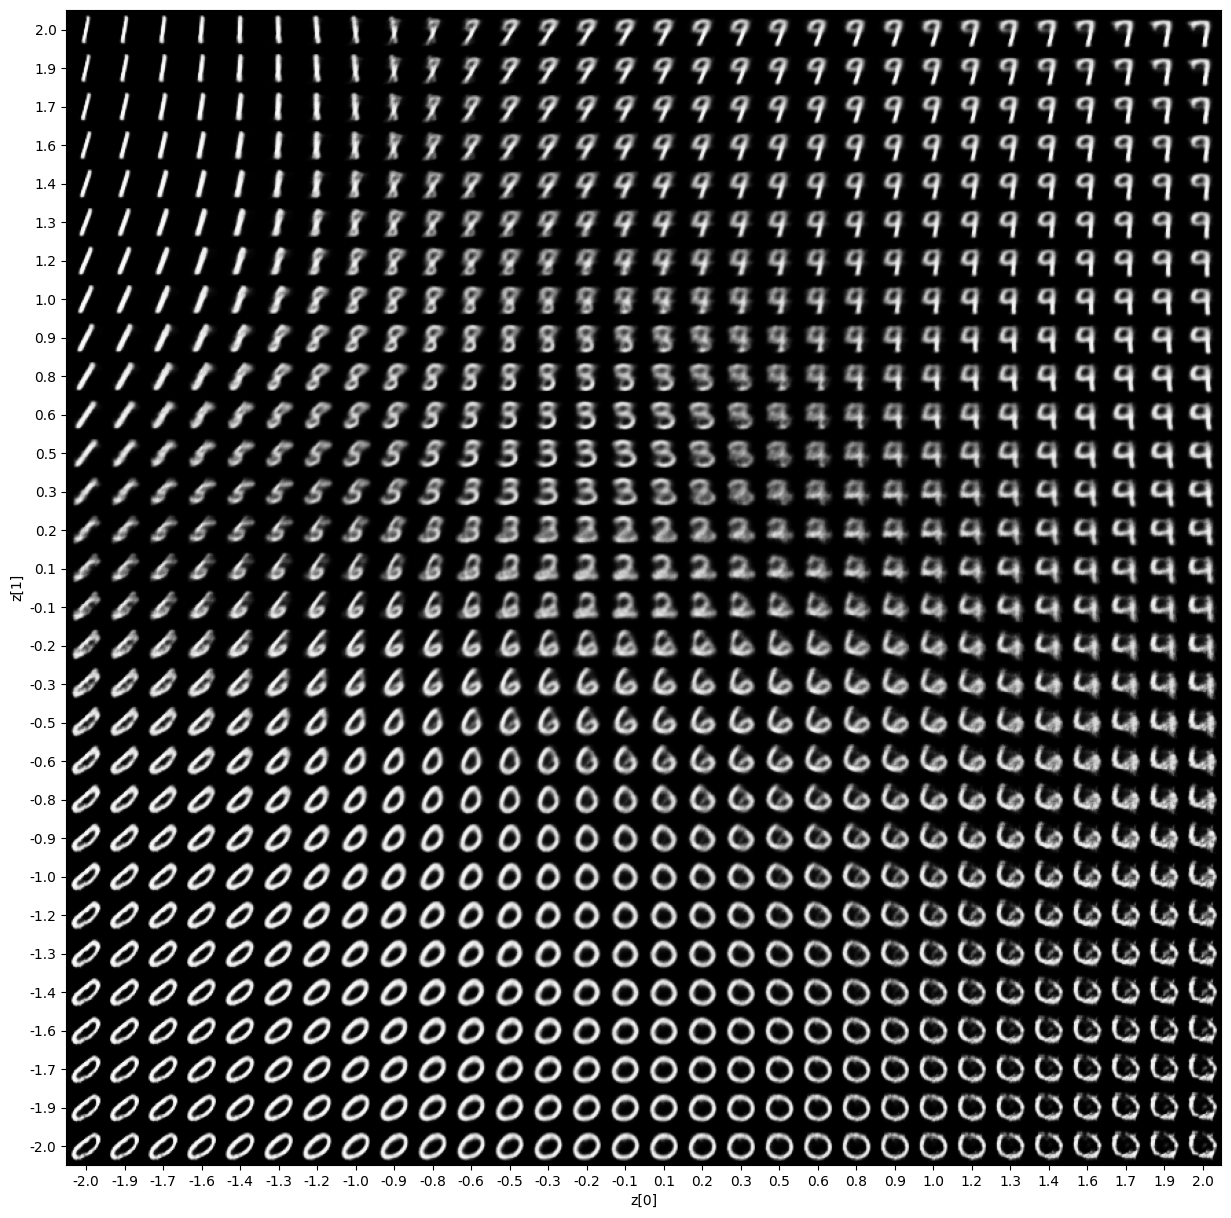

In [11]:
latentSpaceRecons2D(scale=2.0, n=30)

In [12]:
activeUnits(model, trainImageData)

dim 0: Var_x[mu] = 0.855678  (active)
1/2 active units (threshold=0.01)
dim 1: Var_x[mu] = 0.944479  (active)
2/2 active units (threshold=0.01)


tensor([0.8557, 0.9445])

###### Mode Collapse

In [13]:
class mnistDecoder(vaeDecoder):
    """
    Replace sum of error with mean of error - helps to 
    make error independent of dimensionality
    """
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.mean(torch.flatten(bce, start_dim=1), dim=1))

In [14]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = variationalAutoencoder(encoder, decoder).to(device)

In [15]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [16]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_vae/',
                checkPointName='vae_2_avg',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 0.279620 reconLoss: 0.279545 klLoss: 0.000075[12800/60000]
totalLoss: 0.266566 reconLoss: 0.266561 klLoss: 0.000005[25600/60000]
totalLoss: 0.271723 reconLoss: 0.271721 klLoss: 0.000002[38400/60000]
totalLoss: 0.253329 reconLoss: 0.253327 klLoss: 0.000001[51200/60000]
Validation Error: 0.263839
Epoch 2
-------------------------------
totalLoss: 0.254960 reconLoss: 0.254959 klLoss: 0.000001[12800/60000]
totalLoss: 0.268367 reconLoss: 0.268366 klLoss: 0.000001[25600/60000]
totalLoss: 0.265131 reconLoss: 0.265131 klLoss: 0.000000[38400/60000]
totalLoss: 0.267320 reconLoss: 0.267319 klLoss: 0.000000[51200/60000]
Validation Error: 0.263042
Epoch 3
-------------------------------
totalLoss: 0.264576 reconLoss: 0.264576 klLoss: 0.000000[12800/60000]
totalLoss: 0.263135 reconLoss: 0.263135 klLoss: 0.000000[25600/60000]
totalLoss: 0.258115 reconLoss: 0.258115 klLoss: 0.000000[38400/60000]
totalLoss: 0.261719 reconLoss: 0.261719 klLoss: 0.000000

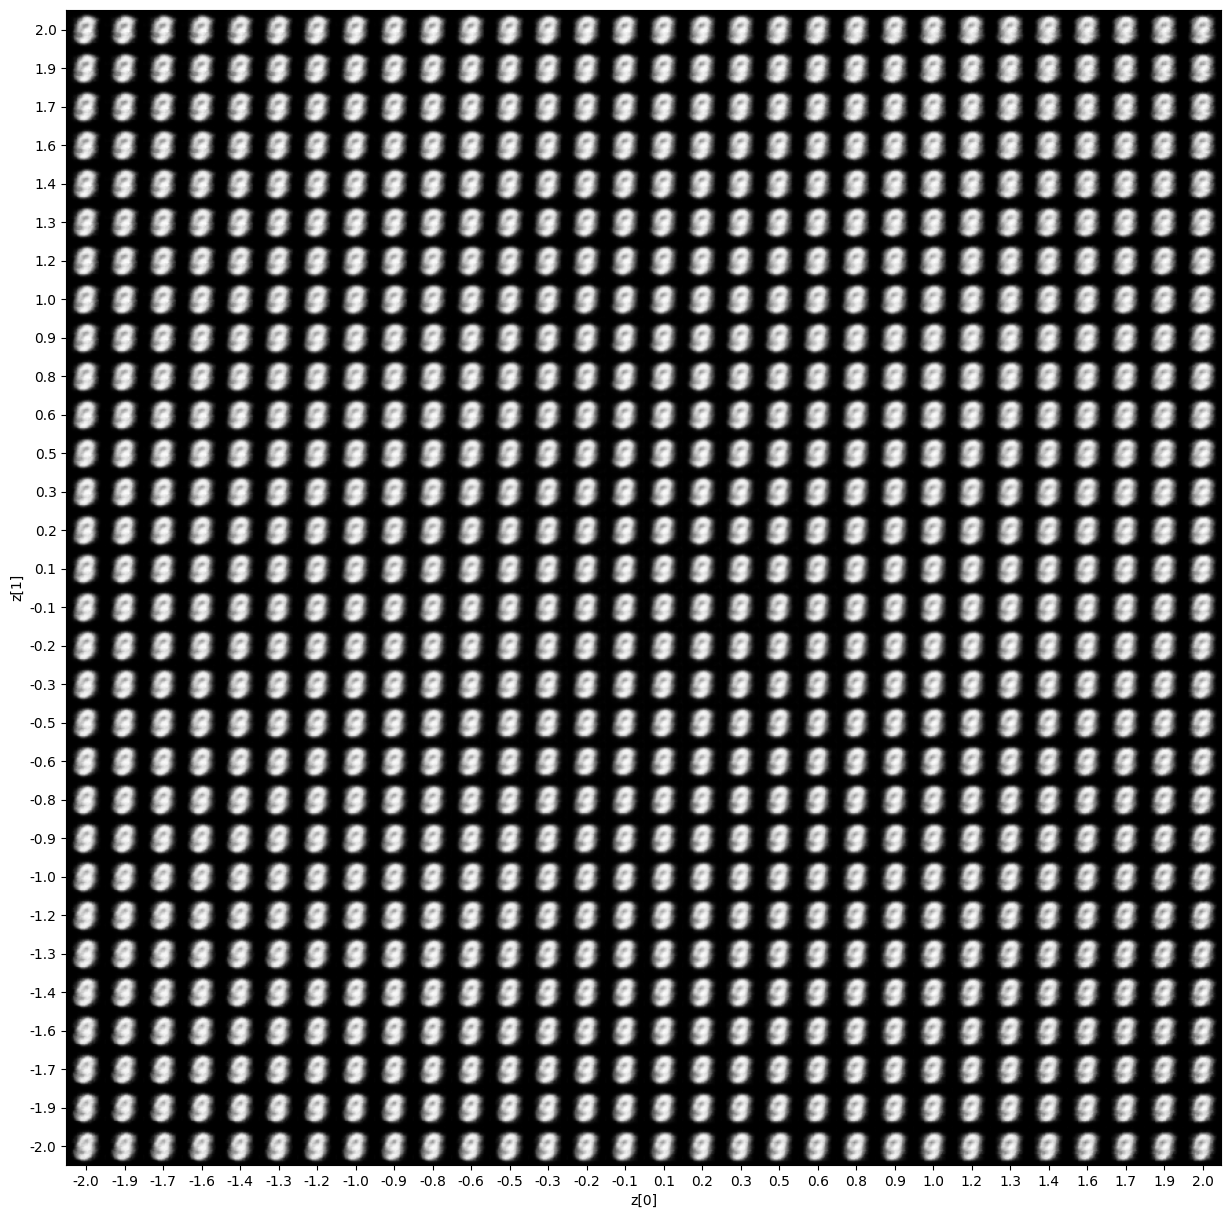

In [17]:
latentSpaceRecons2D(scale=2.0, n=30)

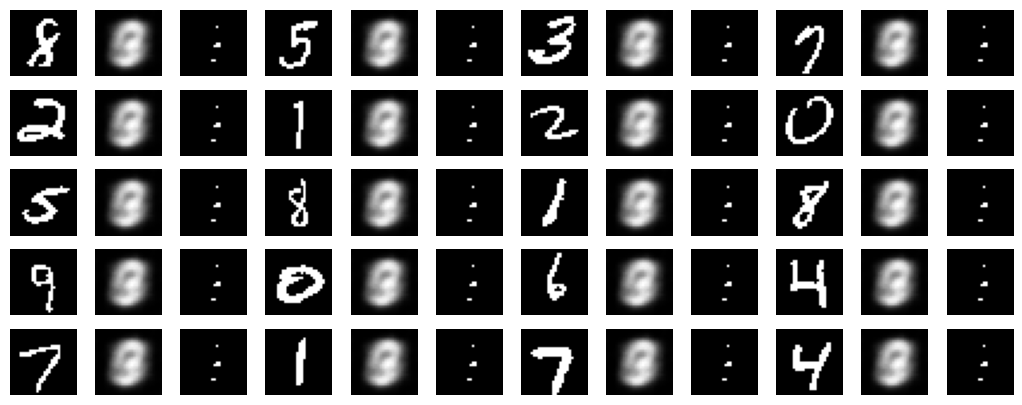

In [18]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model.eval()

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model.decode(model.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [19]:
activeUnits(model, trainImageData)

dim 0: Var_x[mu] = 0.000001  (DEAD)
0/2 active units (threshold=0.01)
dim 1: Var_x[mu] = 0.000001  (DEAD)
0/2 active units (threshold=0.01)


tensor([1.4900e-06, 8.7422e-07])

###### β-VAE

In [20]:
# build the encoder and decoder networks
hid_dim = 2
beta = 0.01

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = variationalAutoencoder(encoder, decoder, beta).to(device)

In [21]:
learning_rate = 1e-3
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.001, mode='min', restoreBestWeights=True)

In [22]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_bvae/',
                checkPointName='bvae_2_2',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 0.276524 reconLoss: 0.266625 klLoss: 0.989891[12800/60000]
totalLoss: 0.240087 reconLoss: 0.226738 klLoss: 1.334987[25600/60000]
totalLoss: 0.233586 reconLoss: 0.218891 klLoss: 1.469559[38400/60000]
totalLoss: 0.231528 reconLoss: 0.217011 klLoss: 1.451694[51200/60000]
Validation Error: 0.226853
Epoch 2
-------------------------------
totalLoss: 0.222425 reconLoss: 0.206284 klLoss: 1.614069[12800/60000]
totalLoss: 0.223488 reconLoss: 0.207872 klLoss: 1.561606[25600/60000]
totalLoss: 0.230997 reconLoss: 0.214229 klLoss: 1.676802[38400/60000]
totalLoss: 0.219174 reconLoss: 0.202648 klLoss: 1.652585[51200/60000]
Validation Error: 0.220142
Epoch 3
-------------------------------
totalLoss: 0.225845 reconLoss: 0.209466 klLoss: 1.637991[12800/60000]
totalLoss: 0.224413 reconLoss: 0.207604 klLoss: 1.680895[25600/60000]
totalLoss: 0.219059 reconLoss: 0.201203 klLoss: 1.785673[38400/60000]
totalLoss: 0.213065 reconLoss: 0.196228 klLoss: 1.683651

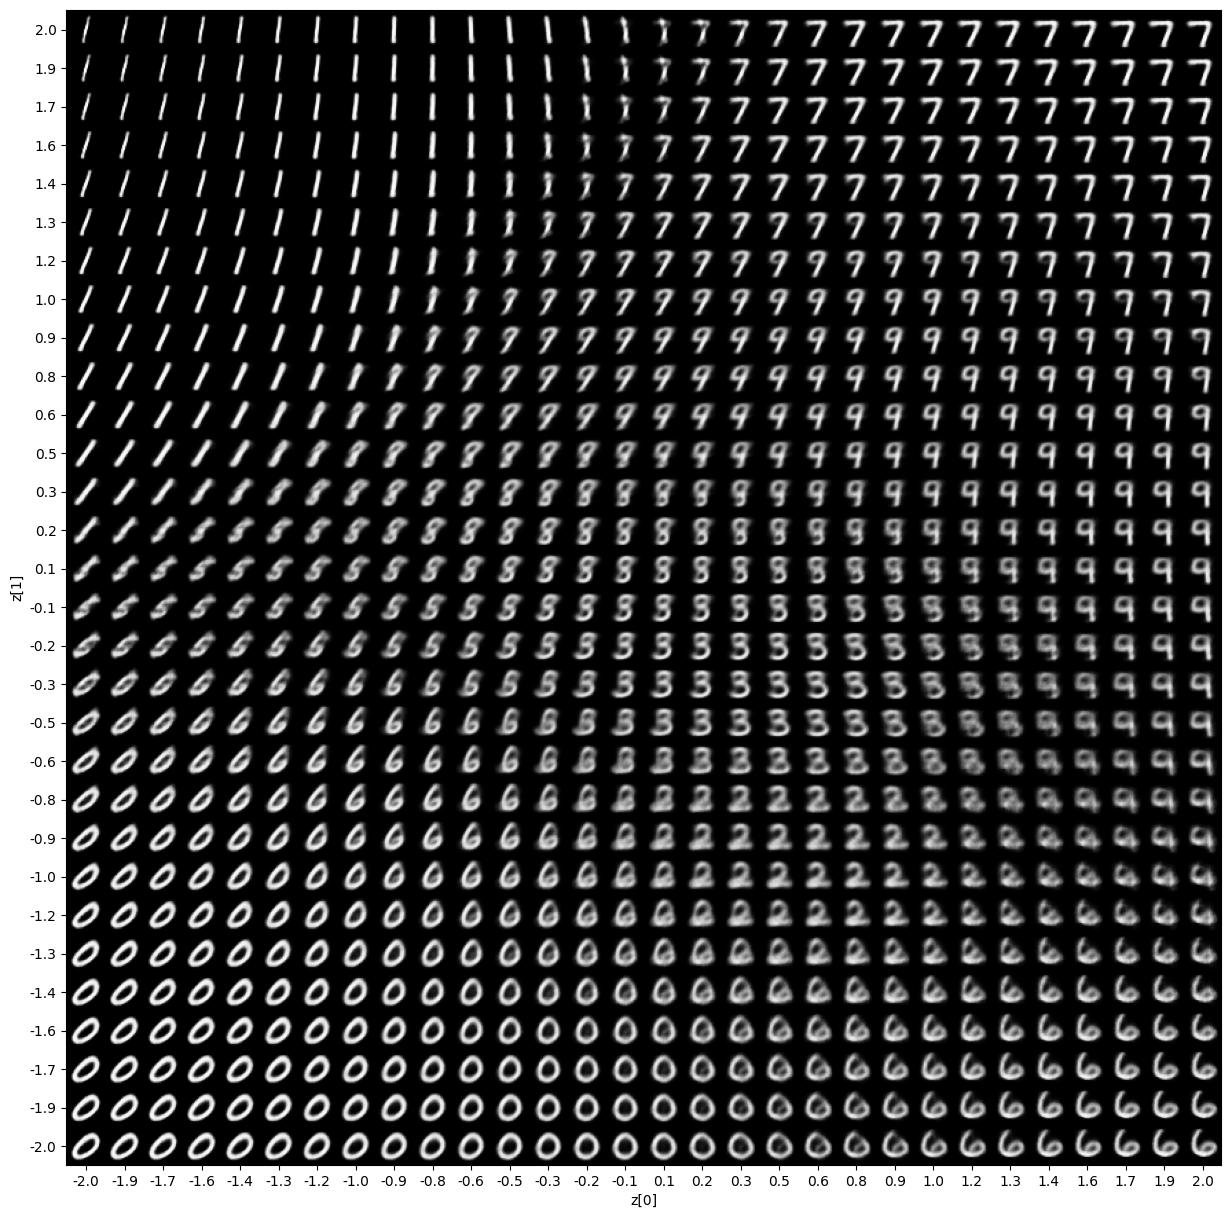

In [23]:
latentSpaceRecons2D(scale=2.0, n=30)

In [24]:
activeUnits(model, trainImageData)

dim 0: Var_x[mu] = 0.906247  (active)
1/2 active units (threshold=0.01)
dim 1: Var_x[mu] = 1.051030  (active)
2/2 active units (threshold=0.01)


tensor([0.9062, 1.0510])

In [25]:
# build the encoder and decoder networks
hid_dim = 64
n_embeds = 10
beta = 1.
# imgs = torch.stack([trainImageData[i] for i in range(len(trainImageData))])
data_var = 0.05 # torch.var(imgs)

In [26]:
encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU())

decoder = nn.Sequential(nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.Sigmoid())

model = vqVariationalAutoencoder(encoder, decoder, nDims=hid_dim, 
                                 nEmbeddings=n_embeds, beta=beta,
                                 data_var=data_var).to(device)

In [27]:
def gradNorm(loss, params, retain_graph):
    grads = torch.autograd.grad(loss, params, retain_graph=retain_graph, allow_unused=True)
    return torch.sqrt(sum(g.pow(2).sum() for g in grads if g is not None)).item()

def compareLossScales(model, batch):
    model.train()
    encoderParams = list(model.encoder.parameters())

    losses = model.computeLoss(batch)

    reconGradNorm = gradNorm(losses['reconLoss'], encoderParams, retain_graph=True)
    vqGradNorm = gradNorm(losses['vqLoss'], encoderParams, retain_graph=False)

    print(f"recon grad norm (encoder): {reconGradNorm:.4f}")
    print(f"vq grad norm (encoder):    {vqGradNorm:.4f}")
    print(f"ratio reconGradNorm/vqGradNorm -> suggested data_var: {reconGradNorm / vqGradNorm:.4f}")

In [28]:
learning_rate = 1e-3
batch_size = 64
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=0.05, mode='min', restoreBestWeights=True)

In [29]:
batch = next(iter(trainLoader)).to(device)
suggestedDataVar = compareLossScales(model, batch)

recon grad norm (encoder): 0.0334
vq grad norm (encoder):    0.3727
ratio reconGradNorm/vqGradNorm -> suggested data_var: 0.0896


In [30]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_vqvae/',
                checkPointName='vqvae_16_10',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 2.322469 reconLoss: 0.055346 codeLoss: 0.607773 commLoss: 0.607773 vqLoss: 1.215546[ 6400/60000]
totalLoss: 2.175983 reconLoss: 0.047987 codeLoss: 0.608125 commLoss: 0.608125 vqLoss: 1.216250[12800/60000]
totalLoss: 2.211621 reconLoss: 0.045282 codeLoss: 0.652988 commLoss: 0.652988 vqLoss: 1.305976[19200/60000]
totalLoss: 1.975435 reconLoss: 0.039866 codeLoss: 0.589056 commLoss: 0.589056 vqLoss: 1.178112[25600/60000]
totalLoss: 2.043590 reconLoss: 0.042459 codeLoss: 0.597209 commLoss: 0.597209 vqLoss: 1.194418[32000/60000]
totalLoss: 1.869711 reconLoss: 0.039277 codeLoss: 0.542084 commLoss: 0.542084 vqLoss: 1.084169[38400/60000]
totalLoss: 2.059016 reconLoss: 0.040888 codeLoss: 0.620623 commLoss: 0.620623 vqLoss: 1.241247[44800/60000]
totalLoss: 1.987656 reconLoss: 0.039780 codeLoss: 0.596023 commLoss: 0.596023 vqLoss: 1.192046[51200/60000]
totalLoss: 2.199054 reconLoss: 0.041758 codeLoss: 0.681949 commLoss: 0.681949 vqLoss: 1.363898[5

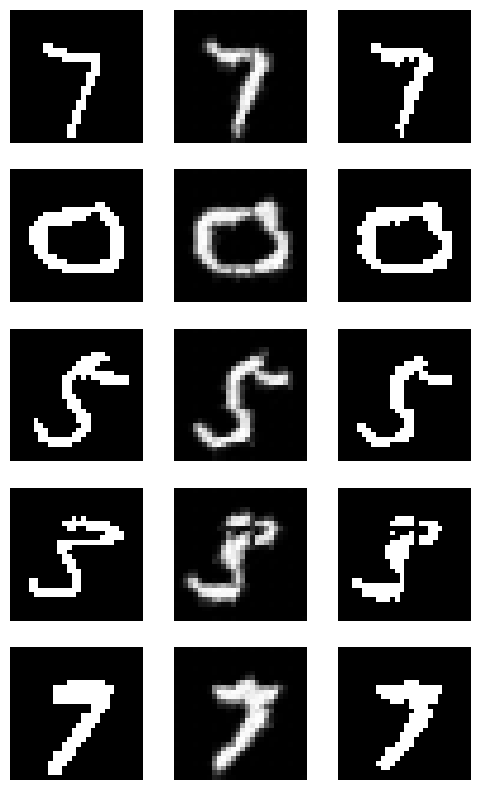

In [31]:
nCols = 3
nRows = 5

figure = plt.figure(figsize=(6, 10))
model.eval()

with torch.no_grad():
    for i in range(nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model.decode(model.encode(trainImageData[sidx].unsqueeze(0).to(device)))
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [32]:
class mnistDecoder(vaeDecoder):
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))
        # return torch.mean(bce)

In [33]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = autoencodingVariationalAutoencoder(encoder, decoder, rho=0.98).to(device)

In [34]:
learning_rate = 1e-3
batch_size = 128
epochs = 25

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=0.05, mode='min', restoreBestWeights=True)

In [35]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_avae/',
                checkPointName='avae_98',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------


TypeError: log(): argument 'input' (position 1) must be Tensor, not float

In [ ]:
plot_latent_space(scale=3.0, n=30)